# Rate Allocator: interactive demo

## Banks and SOFIPOs in Mexico

Most people in Mexico keep everyday savings in a traditional bank or in a SOFIPO. SOFIPOs include a lot of the savings apps people carry on their phones. The two worlds do not follow the same playbook: deposit insurance (how much of your balance is covered if an institution fails) and how interest is taxed can change from one product to another.

Rates also depend on size. The advertised rate often applies only to the first chunk of your balance, then something lower on the rest. Banks and SOFIPOs also shuffle promotions and ceilings fairly often, so what looked best last month is not guaranteed today.

This notebook is a small playground. You type a peso total, pick which names count, and it proposes one way to spread the money so the built-in math favors the modeled return, using practice numbers that ship with the project (not live quotes from a teller). When your posters and caps change, plug the new numbers in and run it again.

The Mexico tax and insurance-style figures the charts use live alongside the other sample material in the project's `data` folder.

## What this tool does

You enter pesos, tick institutions, and the sheet suggests how much to park in each for the demo rates. The tables below pull from the same practice data. It is not legal, tax, banking, or insurance advice. Read what your own providers publish, and talk to someone qualified if you are making real decisions.

## How to use this notebook

1. From the menu, run all cells from top to bottom the first time you open the file (on most apps that sits under Run). Do the same if the screen freezes.
2. When the panel appears, flip the checkboxes for each bank or SOFIPO you want in the mix.
3. Move the slider or use the number box and the + / − keys to set your total in steps of 100 pesos.
4. Scroll down. The table and the plots redraw whenever you change something above.
5. If the output looks empty or stacked twice, run everything from the start again.


## Quick start

Open the notebook and run all cells from top to bottom once so the steps fire in order. The first blocks load the sample banks and rates.


In [1]:
%matplotlib agg
# Non-interactive backend; charts are embedded as PNG inside updatable HTML (no results Output widget).

import os

from ipywidgets import VBox, HBox, Button, FloatSlider, BoundedFloatText, Checkbox, HTML, Layout
from IPython.display import display, clear_output
from traitlets import link as traitlets_link

from rate_allocator import allocate, build_interactive_report_html
from rate_allocator.adapters.yaml_loader import load_institutions_with_overrides

if os.path.basename(os.getcwd()) == 'notebooks':
    data_file = '../data/sample1.yaml'
else:
    data_file = 'data/sample1.yaml'

base_institutions = load_institutions_with_overrides(data_file, {})
print(f"Loaded {len(base_institutions)} institutions from {data_file}")
print("demo_ipywidgets_en UI version: 7 (slider + BoundedFloatText ±100 buttons, traitlets link).")


Loaded 5 institutions from ../data/sample1.yaml
demo_ipywidgets_en UI version: 7 (slider + BoundedFloatText ±100 buttons, traitlets link).


## Your controls

Run the cells under this heading until you see the institution checkboxes and the amount row (slider plus number box).


In [2]:
%load_ext autoreload
%autoreload 2


In [ ]:
def _brief_constraints_label(inst):
    parts = []
    for tier in inst.tiers:
        for c in tier.constraints:
            parts.append(f"{c.type} ${c.cost:.2f}")

    return ", ".join(parts) if parts else "no modeled fees"


_TOTAL_MIN = 0
_TOTAL_MAX = 1_200_000
_TOTAL_DEFAULT = 100_000

allocation_slider = FloatSlider(
    value=_TOTAL_DEFAULT,
    min=_TOTAL_MIN,
    max=_TOTAL_MAX,
    step=1000,
    description='Total (MXN):',
    continuous_update=False,
    readout_format=".0f",
    layout=Layout(width="100%"),
)

allocation_amount = BoundedFloatText(
    value=float(_TOTAL_DEFAULT),
    min=float(_TOTAL_MIN),
    max=float(_TOTAL_MAX),
    step=100,
    description='Same total (type or ±100):',
    layout=Layout(flex="1"),
)


def _snap_total(v: float) -> float:
    v = round(v / 100) * 100
    return float(max(_TOTAL_MIN, min(_TOTAL_MAX, v)))


def _bump_total(delta: float) -> None:
    allocation_amount.value = _snap_total(allocation_amount.value + delta)


minus_100 = Button(description="−", tooltip="Subtract 100 MXN", layout=Layout(width="40px"))
plus_100 = Button(description="+", tooltip="Add 100 MXN", layout=Layout(width="40px"))
minus_100.on_click(lambda _b: _bump_total(-100))
plus_100.on_click(lambda _b: _bump_total(100))

allocation_amount_row = HBox(
    [minus_100, allocation_amount, plus_100],
    layout=Layout(width="100%"),
)

_total_value_link = traitlets_link((allocation_slider, "value"), (allocation_amount, "value"))

institution_checkboxes = {}
for inst in base_institutions:
    hint = _brief_constraints_label(inst)
    cb_label = inst.name if hint == "no modeled fees" else f"{inst.name} ({hint})"
    institution_checkboxes[inst.name] = Checkbox(
        value=True,
        description=cb_label,
        indent=False,
        layout=Layout(width="100%"),
    )

footnote = HTML(
    '<small>Use each <b>Institution</b> checkbox to include or exclude that provider from the optimization.\nText in parentheses summarizes YAML fees or conditions (the allocator applies them when that institution is included).\nHeadline <em>expected return</em> uses the selected horizon with compound gross return minus horizon fees, including estimated ISR over real interest (using the inflation proxy).\nBank withholding is reported separately as cash-flow and is not subtracted in optimization net return.\nThe chart below uses the same allocation with daily-style compounding (m=365) vs simple accrual.</small>'
)

control_panel = VBox(
    [
        HTML('<b>Institutions</b>'),
        *institution_checkboxes.values(),
        footnote,
        allocation_slider,
        allocation_amount_row,
    ],
    layout=Layout(max_width="720px"),
)

display(control_panel)


## What you'll see next

Below the next code cell you get a table and charts tied to whatever you picked above.


### Tables and charts

The next cell draws the table and figures. Change a checkbox or the amount and they refresh.

If the results look blank or printed twice, run all cells from the beginning again.


Institution,Tier,Principal,Nominal rate,Gross return (compound),"Fees (constraints + tax, horizon)",Net return nominal,Net return real
Nu,1,"$25,000",13.00%,"$3,470.05",[1] $12.00,"$3,458.05","$2,405.55"
OpenBank,1,"$40,000",13.00%,"$5,552.08",ISR $34.81,"$5,517.27","$3,833.27"
PlataAhorroPlus,1,"$35,000",12.00%,"$4,461.61","[2] $1,378.08 + ISR $26.89","$3,056.64","$1,583.14"

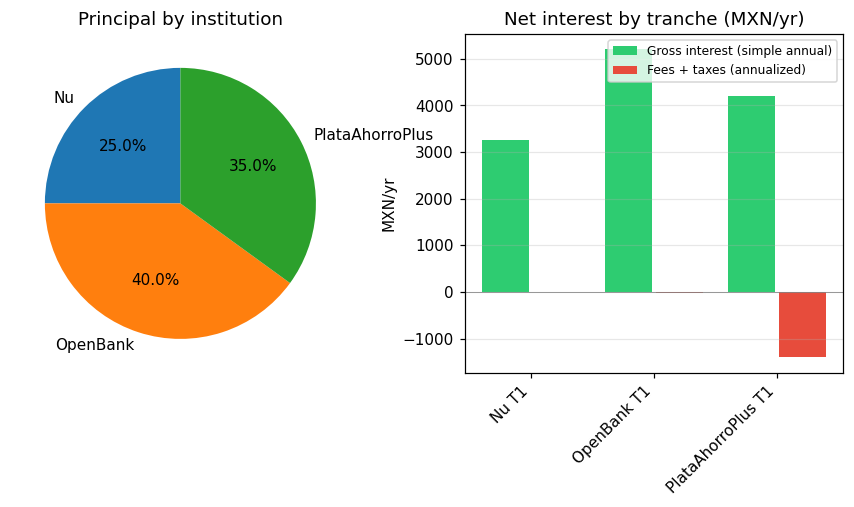
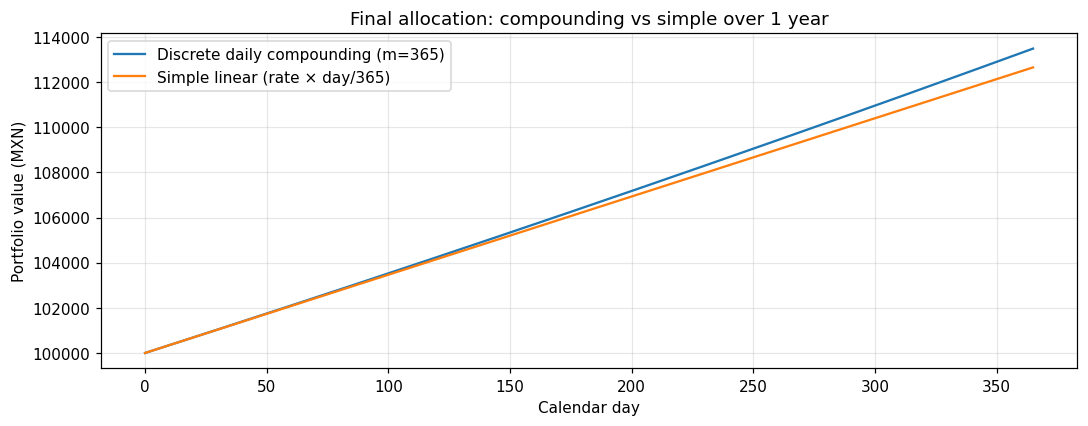

/Users/gera.ledesma/Desktop/Projects/rate-allocator/src/rate_allocator/workflows/interactive_report.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [4]:
import time
from IPython.display import clear_output, display, HTML

# One cell for results + wiring: clear this cell's outputs first (stops stacked HTML/widgets after reopen + Run All).
clear_output(wait=True)

RESULTS_DISPLAY_ID = f"rate-allocator-results-{time.time_ns()}"
display(HTML("<b>Allocation results</b>"))
alloc_results_handle = display(
    HTML("<p><i>Loading...</i></p>"),
    display_id=RESULTS_DISPLAY_ID,
)


def _push_results_html(fragment: str):
    alloc_results_handle.update(HTML(fragment))


def build_selected_institutions():
    return [name for name, checkbox in institution_checkboxes.items() if checkbox.value]


def run_allocation(_=None):
    selected_names = build_selected_institutions()

    if not selected_names:
        _push_results_html('<p>Select at least one institution.</p>')
        return

    all_institutions = load_institutions_with_overrides(data_file, {})
    institutions = [inst for inst in all_institutions if inst.name in selected_names]

    total = allocation_slider.value
    horizon_years = 1.0
    result = allocate(
        total=total,
        institutions=institutions,
        horizon_years=horizon_years,
        periods_per_year=365,
    )

    html_fragment = build_interactive_report_html(
        result,
        institutions,
        total=total,
        horizon_years=horizon_years,
        periods_per_year=365,
    )
    _push_results_html(html_fragment)


for checkbox in institution_checkboxes.values():
    checkbox.unobserve_all(name="value")
allocation_slider.unobserve_all(name="value")

for checkbox in institution_checkboxes.values():
    checkbox.observe(run_allocation, names="value")
allocation_slider.observe(run_allocation, names="value")

run_allocation()


## Notes


In [5]:
print(
    "Institution checkboxes include or exclude each provider from the optimization "
    "(YAML fees and conditions still apply when that institution is included; fees include estimated ISR over real interest, and withholding is shown separately)."
)


Institution checkboxes include or exclude each provider from the optimization (YAML fees and conditions still apply when that institution is included; fees include estimated ISR over real interest, and withholding is shown separately).


The tables subtract fee-style charges from the sample institution rules plus an estimated ISR on real interest over the horizon you use (see the footnotes and the fee columns).

Net return shows up as nominal and real columns. Bank withholding appears elsewhere as a cash-flow style line item; it is not folded into the same net return line the optimizer highlights.

---

## Regulatory disclaimer (Mexico)

Tax and deposit-insurance numbers in the reports use default assumptions from the Mexico regulatory defaults file in the project `data` folder (country MX, effective 2026-01-01). For orientation only: bank deposits show about $3,300,000 MXN per depositor per bank under IPAB (400,000 UDIS in that file); SOFIPO deposits show about $208,000 MXN under Prosofipo (25,000 UDIS). The tax sketch includes 0.9% annual withholding on interest, 0.9% estimated annual ISR on real interest, a 4.21% yearly inflation-style proxy, and for SOFIPOs about $213,973 MXN exempt (5 UMA in that file) with 0.9% ISR on the excess. Real products differ by date and contract. This demo does not certify IPAB or Prosofipo coverage and does not decide your taxes. Check with your institution and a professional before you act.
